In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd

from sklearn.preprocessing import OneHotEncoder

import math


In [4]:
# 1. Load the data from the CSV file into a pandas DataFrame
csv_file_path = '/Users/tvo/Documents/portfolio/college-notes/CSC 180/HR_comma_sep.csv'

df = pd.read_csv(csv_file_path)
print("Original Data:")
print(df.head())
print("-" * 30)

Original Data:
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  

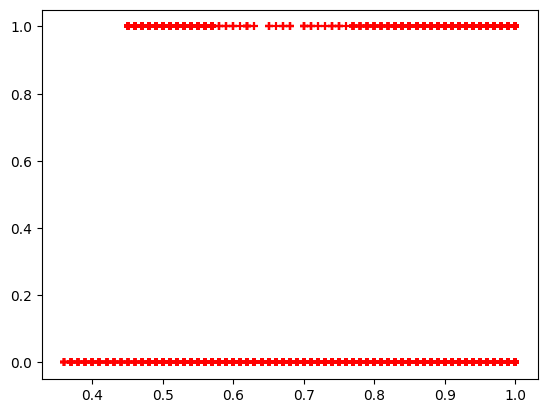

In [5]:
# Plot Data
plt.scatter(df.last_evaluation, df.left, marker='+', color='red')


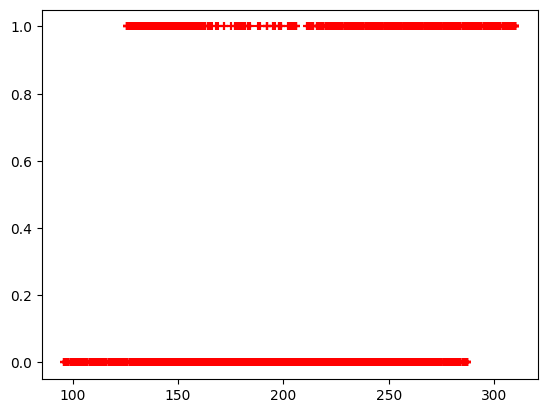

In [6]:
plt.scatter(df.average_montly_hours, df.left, marker='+', color='red')


<BarContainer object of 14999 artists>

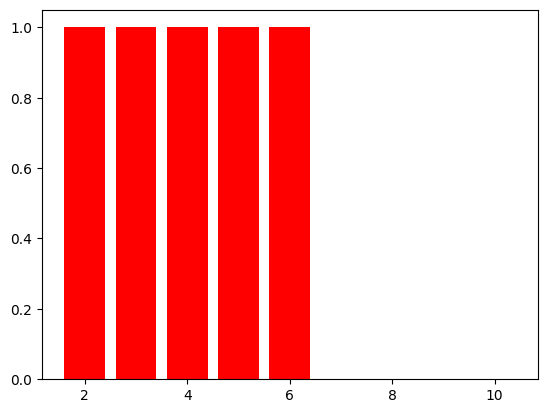

In [7]:
plt.bar(df.time_spend_company, df.left, color='red')


In [8]:
# Find the shape of the data
df.shape

(14999, 10)

In [9]:
# 2. Cleaning Data
# median_bedrooms = math.floor(df.bedrooms.median())
# df.bedrooms = df.bedrooms.fillna(0.0)


In [10]:
# One Hot Encoding 
# ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
 
# one_hot_encoded_array = ohe.fit_transform(df[['Car Model']])
# encoded_df = pd.DataFrame(one_hot_encoded_array, columns=ohe.get_feature_names_out(['Car Model']))
# df_processed_ohe = pd.concat([df.drop('Car Model', axis='columns'), encoded_df], axis='columns')

# print(df_processed_ohe)

In [11]:
# 4. Create and training and test data - DUMMY
target = 'Sell Price($)'
features = [col for col in df_processed.columns if col != target]

X = df_processed[features]
y = df_processed[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



NameError: name 'df_processed' is not defined

In [ ]:
# 4. Create and training and test data - One Hot Encoding
target = 'bought_insurance'
features = [col for col in df.columns if col != target]

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

X_test

,age
8,62
13,29
9,61


In [ ]:
# --- 2. Run Scikit-learn's Linear Regression ---
# Scikit-learn expects a 2D array for features, so we reshape x
model = LinearRegression()
model.fit(X_train, y_train)

print("\n--- Scikit-learn Results ---")
for feature, coef in zip(features, model.coef_):
    print(f"  - {feature}: {coef:.2f}")

print(f"\nModel Intercept: {model.intercept_:.2f}")




--- Scikit-learn Results ---
  - age: 0.02

Model Intercept: -0.40


In [ ]:
# Verify against Test Data
y_results = model.predict(X_test)

from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_results)

print(r2)

0.8744641817714356


In [ ]:
# Predict the Price against new data
# print(X)

candidates_to_predict = [
    [56], 
    [25], 
]

predict_price_score = model.predict(candidates_to_predict)

print("Predictions:")
for i, insurance in enumerate(predict_price_score):
    print(f"Candidate with age - {candidates_to_predict[i]} with is predicted to have insurance is about {predict_price_score[i] * 100 :,.2f}%")



Predictions:
Candidate with age - [56] with is predicted to have insurance is about 91.67%
Candidate with age - [25] with is predicted to have insurance is about 18.72%


/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
